# Testing local CTDS against Adithi's reference (Jha et al. 2024)

Reference repo vendored under [vendor/Cell_type_dynamical_system/](../vendor/Cell_type_dynamical_system/). Two packages live there, both installed editable into this venv via `uv sync --group ref`:
- **`ssm`** — Adithi's ssm fork with the `gaussian_ctds` dynamics + emissions classes.
- **`adithis_utils`** — her `utils/` directory, repackaged so it imports as `from adithis_utils.simulation_utils import ...`.

## Goals (single-region CTDS)

1. **Forward LL parity at ground truth** — push identical params into both models and confirm $\log p(Y\mid\theta_{\text{true}})$ matches.
2. **EM from random init** — fit both, compare LL trajectories, wall time, and recovered parameters.
3. **EM from NMF init** — same as 2 but with the constrained-regression + per-class NMF warm-start the paper uses.
4. **Sanity check** — start ssm at the ground-truth params and confirm Laplace-EM doesn't drift away.
5. **Aligned parameter recovery** — apply a single C-based linear alignment to both fits, report MSEs and side-by-side heatmaps.

## Conventions to keep straight

| | shape per trial | array form |
|---|---|---|
| ssm | `(T, N)` | list of `n_trials` arrays |
| local | `(T, N, 1)` | one `(n_trials, T, N, 1)` array |

Both `ssm.lds.LDS.log_likelihood` and `local.LL` return **per-(trial, timestep)** average LL — no extra normalization needed.

## 0. Setup

In [1]:
import time, warnings, pathlib
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import ssm.lds as ssm_lds 
from adithis_utils.simulation_utils import create_dynamics_matrix
from adithis_utils.nnmf_utils import obtain_params_nnmf_init

from pillow_lab_rotation.ctds import CTDS

if pathlib.Path('../JS.mplstyle').exists():
    plt.style.use('../JS.mplstyle')

## 1. Build a single-region ground-truth CTDS

Pick `Ne, Ni, De, Di, T, n_trials`. Build:
- $A$ via `create_dynamics_matrix(np.array([[De, Di]]))` — Dale's law, single region.
- $C$ as block-positive: top-left $N_e \times D_e$ block of `np.random.rand`, bottom-right $N_i \times D_i$ block of `np.random.rand`, zeros elsewhere.
- $Q$ small PD (e.g. random Wishart-ish, then divide by something so noise is small).
- $R$ small diagonal positive (e.g. `np.diag(rand) / 1000`).
- $\mu_0 = 0$, $Q_0 = I$.

Match the construction in [vendor/Cell_type_dynamical_system/fit_ctds_on_simulated_data.ipynb](../vendor/Cell_type_dynamical_system/fit_ctds_on_simulated_data.ipynb) so you're testing the same regime the paper uses. Print spectral radius of $A$ and PD-checks for $Q$, $R$.

In [49]:
Ne, Ni = 5, 5
N = Ne + Ni
De, Di = 2, 3
D = De + Di

# Single-region: list_of_dimensions has one row, two columns (E, I).
list_of_dimensions = np.array([[De, Di]])

np.random.seed(10)

# Dynamics A: Dale's law within region (no across-region terms in single-region case).
A_true = create_dynamics_matrix(list_of_dimensions)

# Emissions C: top-left Ne x De and bottom-right Ni x Di blocks positive, zeros elsewhere.
C_true = np.zeros((N, D))
C_true[:Ne, :De] = np.random.rand(Ne, De)
C_true[Ne:, De:] = np.random.rand(Ni, Di)

# Latent noise covariance (small, PD).
Q_true = np.random.randn(D, D)
Q_true = Q_true.T @ Q_true + np.eye(D)
Q_true = Q_true / (Q_true.max() * 100)

# Observation noise (diagonal, small, positive).
R_true = np.diag(np.random.rand(N) + 0.1) / 1000

# Initial state.
mu0_true = np.zeros((D, 1))
Q0_true = np.eye(D)

print('A spectral radius:', np.max(np.abs(np.linalg.eigvals(A_true))))
print('Q PD:', bool(np.all(np.linalg.eigvalsh(Q_true) > 0)))
print('R PD:', bool(np.all(np.diag(R_true) > 0)))

A spectral radius: 0.8992820255063975
Q PD: True
R PD: True


## 2. Build the reference model and sample synthetic data

**Build:** instantiate `ssm_lds.LDS(N=N, D=D, M=0, dynamics='gaussian_ctds', emissions='gaussian_ctds', emission_kwargs=..., dynamics_kwargs=...)`. The kwargs need:
- `cell_identity`: integer array of length $N$, `1` for E, `2` for I.
- `region_identity`: integer array of length $N$, all zeros for single region.
- `list_of_dimensions`: shape `(num_regions, 2)`, here `[[De, Di]]`.

**Push ground-truth params:** the relevant attributes are
- `m.dynamics.As[0]`, `m.dynamics.bs[0]`, `m.dynamics._sqrt_Sigmas[0] = chol(Q)`
- `m.dynamics.mu_init[0]`, `m.dynamics.Sigmas_init = np.array([Q0])`
- `m.emissions.Cs[0]`, `m.emissions.ds[0]`, `m.emissions.inv_etas[0] = R` (yes, `inv_etas` stores the covariance for `GaussianCellTypeEmissions` — see `vendor/Cell_type_dynamical_system/ssm/ssm/emissions.py:573`)

**Sample:** call `m.sample(T)` `n_trials` times. Each call returns `(states, data)` of shapes `(T, D)`, `(T, N)`. Build a list `datas` for ssm and a `(n_trials, T, N, 1)` array `Y_local` for your model.

In [50]:
# kwargs for the ssm CTDS model — single region.
cell_identity = np.array([1] * Ne + [2] * Ni)   # 1 = E, 2 = I (0 reserved for unknown)
region_identity = np.zeros(N, dtype=int)        # all neurons in region 0

emission_kwargs = dict(
    cell_identity=cell_identity,
    region_identity=region_identity,
    list_of_dimensions=list_of_dimensions,
)
dynamics_kwargs = dict(list_of_dimensions=list_of_dimensions)

Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints


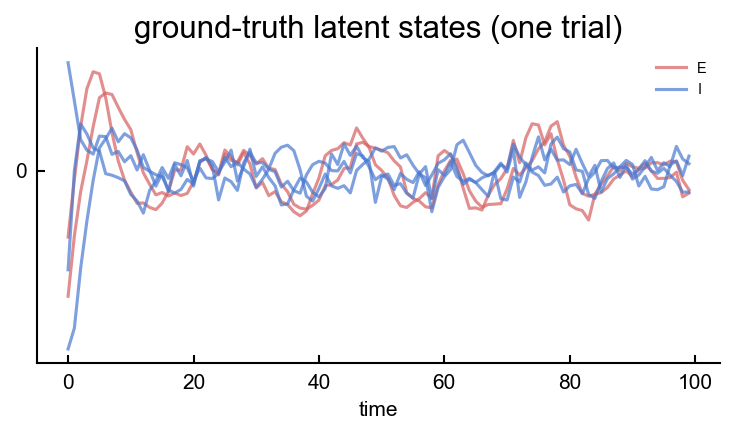

In [51]:
GROUND_TRUTH_MODEL = ssm_lds.LDS(
    N=N, D=D, M=0,
    dynamics='gaussian_ctds',
    emissions='gaussian_ctds',
    emission_kwargs=emission_kwargs,
    dynamics_kwargs=dynamics_kwargs,
)

# Push ground-truth params into the model — without this step ssm samples from
# random-init params instead of from A_true, C_true, etc.
GROUND_TRUTH_MODEL.dynamics.As[0] = A_true
GROUND_TRUTH_MODEL.dynamics.bs[0] = 0
GROUND_TRUTH_MODEL.dynamics._sqrt_Sigmas[0] = np.linalg.cholesky(Q_true)
GROUND_TRUTH_MODEL.emissions.Cs[0] = C_true
GROUND_TRUTH_MODEL.emissions.ds[0] = 0
GROUND_TRUTH_MODEL.emissions.inv_etas[0] = R_true  # `inv_etas` IS the covariance for GaussianCellTypeEmissions
assert np.allclose(GROUND_TRUTH_MODEL.dynamics.Sigmas[0], Q_true), 'Q not set correctly'

# Generate synthetic data from ground truth.
T = 100
num_trials = 50
datas = []
for _ in range(num_trials):
    true_states, data = GROUND_TRUTH_MODEL.sample(T, prefix=None)
    datas.append(data)

# Plot latent trajectories — E in red, I in blue.
fig, ax = plt.subplots(figsize=(5, 3))
for d in range(De):
    ax.plot(true_states[:, d], color='C3', alpha=0.7, label='E' if d == 0 else None)
for d in range(De, D):
    ax.plot(true_states[:, d], color='C0', alpha=0.7, label='I' if d == De else None)
ax.set(xlabel='time', title='ground-truth latent states (one trial)')
ax.set_yticks([0])
ax.set_yticklabels(['0'])
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

In [52]:
adithis_model = ssm_lds.LDS(
    N=N,
    D=D,
    M=0,
    dynamics='gaussian_ctds',
    emissions='gaussian_ctds',
    emission_kwargs=emission_kwargs,
    dynamics_kwargs=dynamics_kwargs
)

jeremys_model = CTDS(
    De=De,
    Di=Di,
    Ne=Ne,
    Ni=Ni
)

Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints


## 3. Forward LL parity at ground truth

- `ref_avg = ref_truth.log_likelihood(datas)` returns the per-(trial, T) average (it divides by `total_time_steps` internally — see `vendor/Cell_type_dynamical_system/ssm/ssm/lds.py:1010`).
- For local: instantiate a fresh `CTDS`, push the truth params, manually run one filter pass (set `local.observations = Y_local`, `local.n_trials, local.T = ...`, `local.inputs = zeros(...)`, then `local.run_filter()`), and read `local.LL`.

The two numbers should match to ~$10^{-10}$. If they don't, the gap is almost always in how the initial state $\mathcal{N}(\mu_0, Q_0)$ is treated at $t=1$.

In [53]:
# Push ground-truth params into Adithi's model.
adithis_model.dynamics.As[0] = A_true
adithis_model.dynamics.bs[0] = 0
adithis_model.dynamics._sqrt_Sigmas[0] = np.linalg.cholesky(Q_true)
adithis_model.emissions.Cs[0] = C_true
adithis_model.emissions.ds[0] = 0
adithis_model.emissions.inv_etas[0] = R_true

# Push ground-truth params into Jeremy's model.
jeremys_model.A = A_true.copy()
jeremys_model.C = C_true.copy()
jeremys_model.Q = Q_true.copy()
jeremys_model.R = R_true.copy()
jeremys_model.mu0 = mu0_true.copy()
jeremys_model.Q0 = Q0_true.copy()

In [54]:
# Local model wants (n_trials, T, N, 1); ssm gives a list of (T, N).
Y_local = np.stack([d[..., None] for d in datas], axis=0)

adithi_ground_truth_LL = adithis_model.log_likelihood(datas)
jeremy_ground_truth_LL = jeremys_model.predict(Y_local)[-1] / (Y_local.shape[0] * Y_local.shape[1])

print(f"Adithi's LL (avg per trial-timestep): {adithi_ground_truth_LL:14.10f}")
print(f"Jeremy's LL (avg per trial-timestep): {jeremy_ground_truth_LL:14.10f}")
print(f'abs diff                              : {abs(adithi_ground_truth_LL - jeremy_ground_truth_LL):.4e}')

Adithi's LL (avg per trial-timestep):  17.3835293491
Jeremy's LL (avg per trial-timestep):  17.3835293491
abs diff                              : 3.9080e-14


## 4. EM from random initialization

- Reference: fresh `make_ref_model()`, then `ref.fit(datas, method='laplace_em', num_iters=100, initialize=True)`. The `initialize=True` runs ssm's PCA + ARHMM init.
- Local: fresh `CTDS(...)`, `local.init_params()` (no args = random init), then `local.fit(Y_local, max_iter=100, verbose=False)`.

Time both, capture the LL trajectory from each, plot them on the same axes against the ground-truth LL line.

In [55]:
# divide into train and test datasets
num_train_trials = int(0.8*num_trials)
train_datas = datas[:num_train_trials]
test_datas = datas[num_train_trials:]

# compute LLs for the test and train datasets
true_model_ll = GROUND_TRUTH_MODEL.log_likelihood(test_datas)
true_model_train_ll = GROUND_TRUTH_MODEL.log_likelihood(train_datas)

In [56]:
adithis_model = ssm_lds.LDS(
    N=N,
    D=D,
    M=0,
    dynamics='gaussian_ctds',
    emissions='gaussian_ctds',
    emission_kwargs=emission_kwargs,
    dynamics_kwargs=dynamics_kwargs
)

jeremys_model = CTDS(
    De=De,
    Di=Di,
    Ne=Ne,
    Ni=Ni
)
jeremys_model.init_params()

# Make both models start from the SAME init — push Jeremy's random-init params
# into Adithi's model, then fit Adithi's with initialize=False so ssm doesn't
# overwrite the shared starting point.
adithis_model.dynamics.As[0] = jeremys_model.A
adithis_model.dynamics.bs[0] = 0
adithis_model.dynamics._sqrt_Sigmas[0] = np.linalg.cholesky(jeremys_model.Q)
adithis_model.dynamics.mu_init[0] = jeremys_model.mu0[:, 0]
adithis_model.dynamics.Sigmas_init = np.array([jeremys_model.Q0])
adithis_model.emissions.Cs[0] = jeremys_model.C
adithis_model.emissions.ds[0] = 0
adithis_model.emissions.inv_etas[0] = jeremys_model.R

lls,_ = adithis_model.fit(
    train_datas,
    method="laplace_em",
    num_iters = 100,
    initialize=False,
)

Y_train = np.stack([d[..., None] for d in train_datas], axis=0)
jeremys_model.fit(Y_train, verbose=True, criterion=1e-6)

Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints


  0%|          | 0/100 [00:00<?, ?it/s]

Converged at iteration 82
Iteration 0: LL = -10.898349
Iteration 1: LL = 4.777114
Iteration 2: LL = 8.799323
Iteration 3: LL = 11.713982
Iteration 4: LL = 12.993548
Iteration 5: LL = 13.936519
Iteration 6: LL = 14.596738
Iteration 7: LL = 15.038194
Iteration 8: LL = 15.383254
Iteration 9: LL = 16.036470
Iteration 10: LL = 16.667084
Iteration 11: LL = 17.030707
Iteration 12: LL = 17.201042
Iteration 13: LL = 17.281612
Iteration 14: LL = 17.323241
Iteration 15: LL = 17.346734
Iteration 16: LL = 17.361062
Iteration 17: LL = 17.370417
Iteration 18: LL = 17.376827
Iteration 19: LL = 17.381356
Iteration 20: LL = 17.384689
Iteration 21: LL = 17.387210
Iteration 22: LL = 17.389156
Iteration 23: LL = 17.390684
Iteration 24: LL = 17.391903
Iteration 25: LL = 17.392888
Iteration 26: LL = 17.393695
Iteration 27: LL = 17.394363
Iteration 28: LL = 17.394924
Iteration 29: LL = 17.395399
Iteration 30: LL = 17.395807
Iteration 31: LL = 17.396160
Iteration 32: LL = 17.396469
Iteration 33: LL = 17.396741

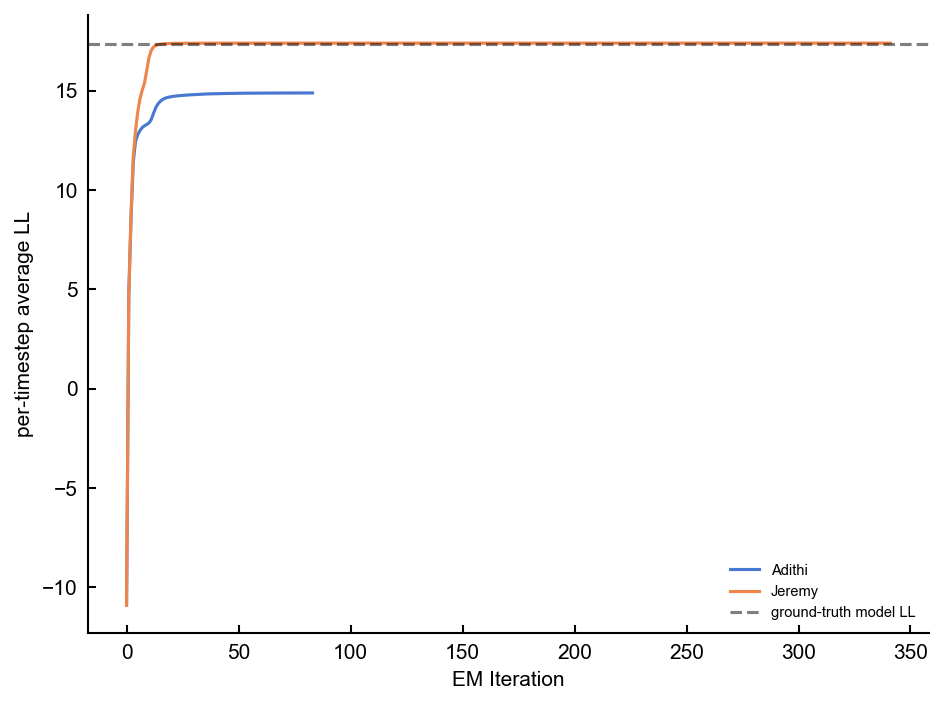

                      test LL
------------------------------
ground truth        17.447936
Adithi              14.728235
Jeremy              17.454589


In [57]:
plt.plot(
    lls,
    label='Adithi'
)
plt.plot(jeremys_model.ll_history, label='Jeremy')
plt.axhline(true_model_train_ll, ls='--', color='k', alpha=0.5, label='ground-truth model LL')

plt.legend()
plt.xlabel('EM Iteration')
plt.ylabel('per-timestep average LL')
plt.show()
# Test-set LL comparison.
Y_test = np.stack([d[..., None] for d in test_datas], axis=0)
n_test, T_test = Y_test.shape[:2]

adithi_test_ll = adithis_model.log_likelihood(test_datas)
jeremy_test_ll = jeremys_model.predict(Y_test)[-1] / (n_test * T_test)

print(f"{'':<14} {'test LL':>14}")
print('-' * 30)
print(f"{'ground truth':<14} {true_model_ll:14.6f}")
print(f"{'Adithi':<14} {adithi_test_ll:14.6f}")
print(f"{'Jeremy':<14} {jeremy_test_ll:14.6f}")

## 5. EM from NMF initialization

- Get NMF estimates of $A$ and $C$ from the data: `signs = np.array([1]*Ne + [2]*Ni)`, then `A_nmf, C_nmf = obtain_params_nnmf_init(seed=0, datas=datas, signs=signs, rank_e=De, rank_i=Di)`.
- Reference: fresh model, **first call** `ref.initialize(datas, inputs=[zeros((T,0)) for _ in datas], masks=..., tags=...)` to get sane PD $Q$ and $R$, **then** overwrite `ref.dynamics.As[0] = A_nmf` and `ref.emissions.Cs[0] = C_nmf`. Now `ref.fit(..., initialize=False)`. (If you skip the `initialize` call, ssm's filter crashes on a non-PD random Q.)
- Local: fresh `CTDS(...)`, `local.init_params(observations=Y_local, start_seed=0)` (this internally runs the same constrained regression + per-class NMF via `EIRNNInit` and additionally fits Q, R, mu0, Q0 from residuals).

In [58]:
adithis_model = ssm_lds.LDS(
    N=N,
    D=D,
    M=0,
    dynamics='gaussian_ctds',
    emissions='gaussian_ctds',
    emission_kwargs=emission_kwargs,
    dynamics_kwargs=dynamics_kwargs
)

jeremys_model = CTDS(
    De=De,
    Di=Di,
    Ne=Ne,
    Ni=Ni
)
jeremys_model.init_params(Y_train)

# Make both models start from the SAME init — push Jeremy's random-init params
# into Adithi's model, then fit Adithi's with initialize=False so ssm doesn't
# overwrite the shared starting point.
adithis_model.dynamics.As[0] = jeremys_model.A
adithis_model.dynamics.bs[0] = 0
adithis_model.dynamics._sqrt_Sigmas[0] = np.linalg.cholesky(jeremys_model.Q)
adithis_model.dynamics.mu_init[0] = jeremys_model.mu0[:, 0]
adithis_model.dynamics.Sigmas_init = np.array([jeremys_model.Q0])
adithis_model.emissions.Cs[0] = jeremys_model.C
adithis_model.emissions.ds[0] = 0
adithis_model.emissions.inv_etas[0] = jeremys_model.R

lls,_ = adithis_model.fit(
    train_datas,
    method="laplace_em",
    num_iters = 100,
    initialize=False,
)

jeremys_model.fit(Y_train, verbose=True, criterion=1e-6)

Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints


  0%|          | 0/100 [00:00<?, ?it/s]

Converged at iteration 15
Iteration 0: LL = 14.061867
Iteration 1: LL = 16.481504
Iteration 2: LL = 16.757503
Iteration 3: LL = 16.922140
Iteration 4: LL = 17.036596
Iteration 5: LL = 17.115279
Iteration 6: LL = 17.166545
Iteration 7: LL = 17.199405
Iteration 8: LL = 17.222064
Iteration 9: LL = 17.240371
Iteration 10: LL = 17.257744
Iteration 11: LL = 17.275645
Iteration 12: LL = 17.294093
Iteration 13: LL = 17.312053
Iteration 14: LL = 17.328114
Iteration 15: LL = 17.341314
Iteration 16: LL = 17.351522
Iteration 17: LL = 17.359197
Iteration 18: LL = 17.364968
Iteration 19: LL = 17.369358
Iteration 20: LL = 17.372748
Iteration 21: LL = 17.375411
Iteration 22: LL = 17.377527
Iteration 23: LL = 17.379233
Iteration 24: LL = 17.380621
Iteration 25: LL = 17.381762
Iteration 26: LL = 17.382707
Iteration 27: LL = 17.383502
Iteration 28: LL = 17.384176
Iteration 29: LL = 17.384751
Iteration 30: LL = 17.385245
Iteration 31: LL = 17.385674
Iteration 32: LL = 17.386051
Iteration 33: LL = 17.38638

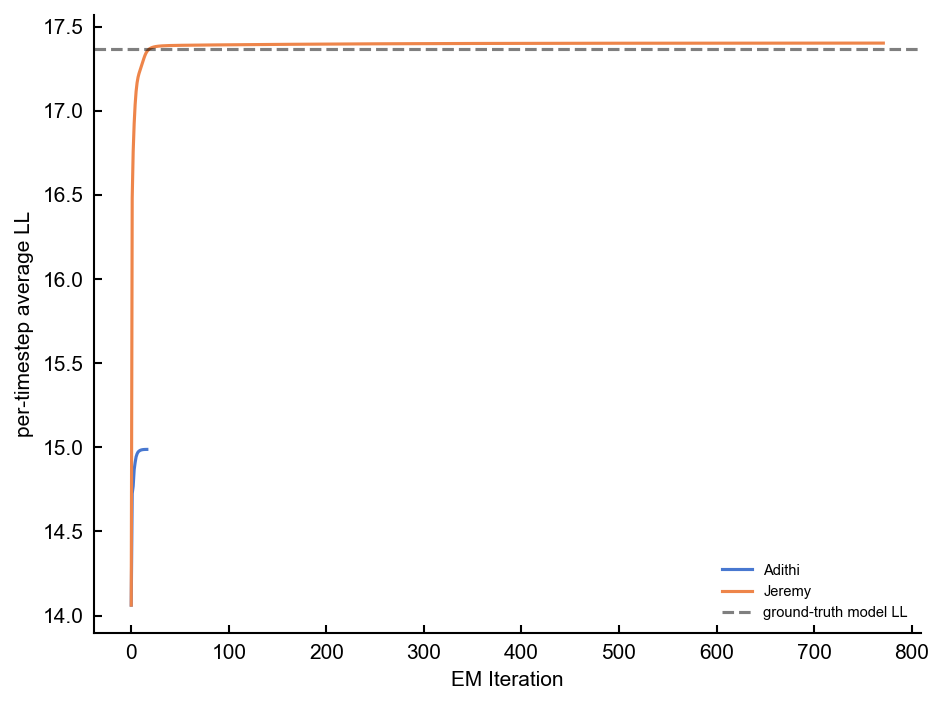

                      test LL
------------------------------
ground truth        17.447936
Adithi              14.858167
Jeremy              17.454039


In [59]:
plt.plot(
    lls,
    label='Adithi'
)
plt.plot(jeremys_model.ll_history, label='Jeremy')
plt.axhline(true_model_train_ll, ls='--', color='k', alpha=0.5, label='ground-truth model LL')

plt.legend()
plt.xlabel('EM Iteration')
plt.ylabel('per-timestep average LL')
plt.show()
# Test-set LL comparison.
Y_test = np.stack([d[..., None] for d in test_datas], axis=0)
n_test, T_test = Y_test.shape[:2]

adithi_test_ll = adithis_model.log_likelihood(test_datas)
jeremy_test_ll = jeremys_model.predict(Y_test)[-1] / (n_test * T_test)

print(f"{'':<14} {'test LL':>14}")
print('-' * 30)
print(f"{'ground truth':<14} {true_model_ll:14.6f}")
print(f"{'Adithi':<14} {adithi_test_ll:14.6f}")
print(f"{'Jeremy':<14} {jeremy_test_ll:14.6f}")

## 5b. Sanity check: ssm warm-started at ground truth

Push the true params into a fresh ssm model and run ~20 EM iters with `initialize=False`. If LL stays at the truth value, ssm's M-steps preserve the optimum and any bad final LLs in §4–5 are init/landscape issues. If LL drops, the Laplace E-step's variational approximation is biased enough that even at the optimum the M-step moves to a strictly worse point.

In [12]:
# TODO: warm-start ssm at truth, fit a few iters, plot LL trajectory vs truth.

## 6. Aligned parameter recovery

Latents are only identifiable up to invertible $H \in \mathbb{R}^{D\times D}$. Solve for $H = (C_{\text{fit}}^\top C_{\text{fit}})^{-1} C_{\text{fit}}^\top C_{\text{true}}$ once per fit, then compare:
- $A_{\text{aligned}} = H^{-1} A_{\text{fit}} H$
- $C_{\text{aligned}} = C_{\text{fit}} H$
- $Q_{\text{aligned}} = H^{-1} Q_{\text{fit}} H^{-\top}$
- $R$ doesn't transform (observation-space).

This is the same alignment used in [scripts/ctds_recovery.py](../scripts/ctds_recovery.py). Adithi's repo uses a different scheme (per-block correlation-based permutation + per-column scaling, see `transform_true_rec` in [vendor/Cell_type_dynamical_system/utils/simulation_utils.py](../vendor/Cell_type_dynamical_system/utils/simulation_utils.py)) — fine to use either, but use the **same** one for both fits to keep the comparison fair.

Reference fit lives at:
- `ref.dynamics.As[0]`, `ref.dynamics.Sigmas[0]` (note: `Sigmas`, not `_sqrt_Sigmas`)
- `ref.emissions.Cs[0]`, `ref.emissions.inv_etas[0]` (which IS the covariance R for this emission class)

Print MSEs in a table; show A and C heatmaps side by side (true + 4 fits).

                   Adithi         Jeremy
----------------------------------------
A MSE        6.936575e-02   3.046948e-04
C MSE        4.613674e-06   1.747268e-06
Q MSE        7.388815e-05   8.459512e-09
R MSE        2.970483e-08   8.518806e-11


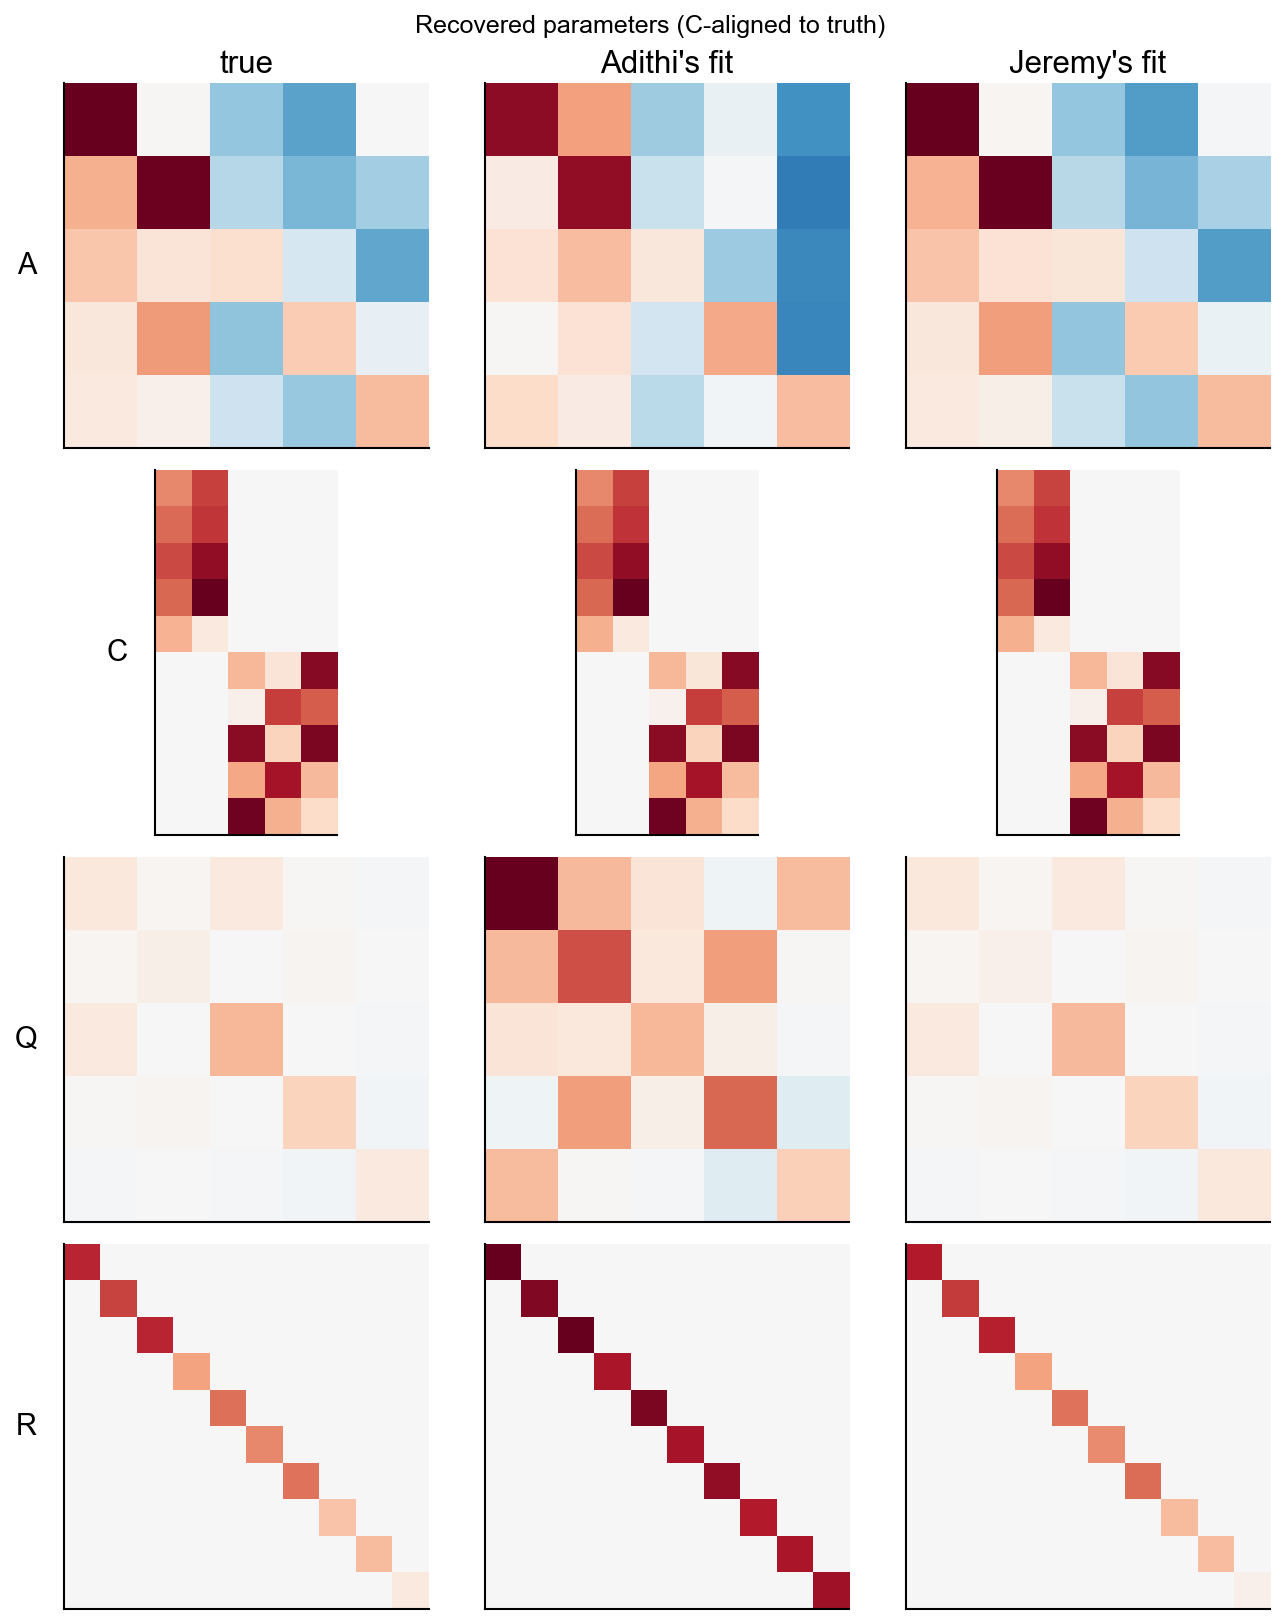

In [60]:
def align(A_fit, C_fit, Q_fit, R_fit, C_true):
    """Align via H = (C'^T C')^-1 C'^T C_true. R is observation-space, doesn't transform."""
    H = np.linalg.inv(C_fit.T @ C_fit) @ C_fit.T @ C_true
    H_inv = np.linalg.inv(H)
    return H_inv @ A_fit @ H, C_fit @ H, H_inv @ Q_fit @ H_inv.T, R_fit

# Pull out fitted params from both models.
A_a_raw = adithis_model.dynamics.As[0]
C_a_raw = adithis_model.emissions.Cs[0]
Q_a_raw = adithis_model.dynamics.Sigmas[0]
R_a_raw = adithis_model.emissions.inv_etas[0]

A_a, C_a, Q_a, R_a = align(A_a_raw, C_a_raw, Q_a_raw, R_a_raw, C_true)
A_j, C_j, Q_j, R_j = align(jeremys_model.A, jeremys_model.C, jeremys_model.Q, jeremys_model.R, C_true)

mats = [
    ('A', A_true, A_a, A_j),
    ('C', C_true, C_a, C_j),
    ('Q', Q_true, Q_a, Q_j),
    ('R', R_true, R_a, R_j),
]
col_titles = ['true', "Adithi's fit", "Jeremy's fit"]

fig, axes = plt.subplots(4, 3, figsize=(9, 11))
for row, (name, t, a, j) in enumerate(mats):
    vmax = max(np.abs(t).max(), np.abs(a).max(), np.abs(j).max())
    for col, M in enumerate([t, a, j]):
        ax = axes[row, col]
        im = ax.imshow(M, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        if row == 0:
            ax.set_title(col_titles[col])
        if col == 0:
            ax.set_ylabel(name, rotation=0, labelpad=18, fontsize=14, va='center')
        ax.set_xticks([])
        ax.set_yticks([])
    # fig.colorbar(im, ax=axes[row].tolist(), shrink=0.85)

fig.suptitle('Recovered parameters (C-aligned to truth)')
fig.tight_layout()

# MSE table.
def mse(a, b):
    return float(np.mean((a - b) ** 2))

print(f'{"":<10} {"Adithi":>14} {"Jeremy":>14}')
print('-' * 40)
for name, t, a, j in mats:
    print(f'{name + " MSE":<10} {mse(a, t):14.6e} {mse(j, t):14.6e}')

## 7. Save results

Dump everything to `../results/ref_comparison.npz` (params true + all four fits, LL trajectories, wall times) so you can re-plot without re-running EM.

In [14]:
# TODO: np.savez_compressed(out, ...).